<a href="https://colab.research.google.com/github/mdanmek/nida-dads-notes/blob/main/dads5001-data-tools/project/eda/03_construction_eda_2569.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# การสำรวจรายการสัญญาจ้างก่อสร้าง ปีงบประมาณ 2569

ข้อมูล e-GP ปีงบประมาณ 2569 สะสมถึงวันที่ 30 กรกฎาคม 2569 ไม่ใช่ข้อมูลเต็มปี

หน่วยวิเคราะห์ของ Notebook นี้คือหนึ่งชุด `รหัสโครงการ + เลขประจำตัวนิติบุคคล 13 หลัก + เลขที่สัญญา`


In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)


In [3]:
base_dir = Path('/content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract')

data_path = base_dir / 'processed' / 'construction_contract_supplier_records_2569.csv'
output_path = base_dir / 'processed' / 'construction_contract_supplier_study_scope_2569.csv'

project_dir = base_dir.parents[2]
figure_dir = project_dir / 'figure'
figure_dir.mkdir(parents=True, exist_ok=True)

print(f'Input file: {data_path}')
print(f'Output file: {output_path}')
print(f'Figure directory: {figure_dir}')


Input file: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_contract_supplier_records_2569.csv
Output file: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_contract_supplier_study_scope_2569.csv
Figure directory: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure


## 1. เปิดข้อมูลรายการสัญญา


In [4]:
contract_supplier_data = pd.read_csv(data_path)

print(f'Shape: {contract_supplier_data.shape}')
display(contract_supplier_data.head())


Shape: (179716, 29)


,ลำดับ,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อประเภทโครงการ,ชื่อหน่วยงาน,ชื่อหน่วยงานย่อย,ชื่อวิธีการจัดซื้อจัดจ้าง,ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง,วันที่ประกาศจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคากลาง (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),ปีงบประมาณ,วันที่เกิดรายการ,จังหวัด,เขต/อำเภอ,แขวง/ตำบล,สถานะโครงการ,พิกัดของโครงการ,ละติจูดของโครงการ,ลองจิจูดของโครงการ,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,เลขที่สัญญา,วันที่ลงนามในสัญญา,วันที่สิ้นสุดสัญญา,วงเงินงบประมาณในสัญญา (บาท),สถานะสัญญา,source_file
0,2,67079254388,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างศูนย์การแ...,จ้างก่อสร้าง,กรุงเทพมหานคร,สำนักการโยธา กรุงเทพมหานคร,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,8 ก.ค. 68,"4,000,000,000.00","4,000,000,000.00","3,997,800,000.00",2569,7 ม.ค. 69,กรุงเทพมหานคร,ดินแดง,ดินแดง,ระหว่างดำเนินการ,POINT(100.51196175293 13.743704315315),13.74,100.51,0107537000939,บริษัท อิตาเลียนไทย ดีเวล๊อปเมนต์ จำกัด (มหาชน),กคส.สนย.๒๒-๕-๖๙,7 ม.ค. 69,26 พ.ค. 73,"3,997,800,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
1,3,68049277788,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ...,จ้างก่อสร้าง,การไฟฟ้านครหลวง,ฝ่ายบริหารโครงการ การไฟฟ้านครหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,15 ก.ย. 68,"4,083,120,000.00","3,872,008,000.00","3,870,550,927.00",2569,29 เม.ย. 69,กรุงเทพมหานคร,คลองเตย,คลองเตย,ระหว่างดำเนินการ,"POLYGON((100.64566612244 13.762437066514,100.6...",13.79,100.69,0993000532988,กิจการร่วมค้า จีบีที,MP8-3404-ABL,29 เม.ย. 69,-,"3,870,550,927.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
2,5,68109204474,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างสถาบันมะเ...,จ้างก่อสร้าง,สถาบันมะเร็งแห่งชาติ,สถาบันมะเร็งแห่งชาติ,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,6 ม.ค. 69,"3,300,000,000.00","3,407,005,257.46","3,285,000,000.00",2569,10 มิ.ย. 69,กรุงเทพมหานคร,ราชเทวี,ทุ่งพญาไท,ระหว่างดำเนินการ,"POLYGON((100.41905164719 13.570553229914,100.4...",13.57,100.42,0107547000273,บริษัท เอ็นแอล ดีเวลลอปเมนต์ จำกัด (มหาชน),192/2569 (พ),10 มิ.ย. 69,15 พ.ค. 74,"3,285,000,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
3,6,68069459174,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ...,จ้างก่อสร้าง,การไฟฟ้านครหลวง,ฝ่ายบริหารโครงการ การไฟฟ้านครหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,28 พ.ย. 68,"3,370,500,000.00","3,285,232,000.00","3,282,800,000.00",2569,29 มิ.ย. 69,กรุงเทพมหานคร,คลองเตย,คลองเตย,ระหว่างดำเนินการ,"LINESTRING(100.62686920166 13.926236380743,100...",13.88,100.60,0993000536215,กิจการร่วมค้า เอสดับเบิ้ลยูซี,MP8-3402-ABL,29 มิ.ย. 69,10 ธ.ค. 72,"3,282,800,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv
4,7,67099642340,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างปรับปรุงข...,จ้างก่อสร้าง,การประปาส่วนภูมิภาค,กองจัดหา การประปาส่วนภูมิภาค,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,16 ก.ค. 68,"3,498,760,900.00","3,498,752,340.00","3,250,900,000.00",2569,20 พ.ย. 68,กรุงเทพมหานคร,หลักสี่,ตลาดบางเขน,ระหว่างดำเนินการ,POINT(98.5303660281 8.4326626992),8.43,98.53,0105519003571,บริษัท วงษ์สยามก่อสร้าง จำกัด,กจห.123/2568,20 พ.ย. 68,23 เม.ย. 71,"3,250,900,000.00",ระหว่างดำเนินการ,2569-egp-contract-1.csv


In [5]:
# ดาวน์โหลดฟอนต์สำหรับแสดงภาษาไทยในกราฟ
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

fm.fontManager.addfont('thsarabunnew-webfont.ttf')

sns.set_theme(style='whitegrid', font='TH Sarabun New')
plt.rcParams.update({
    'axes.titlesize': 18,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.unicode_minus': False
})

BLUE = '#5B7FA3'
ORANGE = '#D9822B'
GRAY = '#B8C2CC'
TEXT = '#344054'
GRID = '#E4E7EC'


In [6]:
project_id_column = 'รหัสโครงการ'
supplier_id_column = 'เลขประจำตัวนิติบุคคล 13 หลัก'
contract_column = 'เลขที่สัญญา'
contract_value_column = 'วงเงินงบประมาณในสัญญา (บาท)'
method_column = 'ชื่อวิธีการจัดซื้อจัดจ้าง'


ข้อมูลแต่ละแถวเป็นรายการสัญญา–ผู้รับจ้างตามชุดคีย์ที่กำหนดไว้ใน Notebook 02 การนับรายการต่อจากนี้จึงนับจำนวนแถวโดยตรง


## 2. ภาพรวมมูลค่าสัญญา


In [7]:
contract_summary = contract_supplier_data[contract_value_column].describe().to_frame('ค่า')
display(contract_summary)


,ค่า
count,"179,626.00"
mean,"2,508,973.44"
std,"28,682,684.49"
min,900.00
25%,"176,441.97"
50%,"381,600.00"
75%,"499,000.00"
max,"3,997,800,000.00"


In [8]:
common_contract_values = (
    contract_supplier_data[contract_value_column]
    .value_counts()
    .head(10)
    .rename_axis(contract_value_column)
    .reset_index(name='จำนวนรายการสัญญา')
)

display(common_contract_values)


,วงเงินงบประมาณในสัญญา (บาท),จำนวนรายการสัญญา
0,"499,000.00",2903
1,"498,000.00",2535
2,"495,000.00",1849
3,"490,000.00",1510
4,"497,000.00",1501
5,"200,000.00",1441
6,"500,000.00",1424
7,"100,000.00",1300
8,"496,000.00",1049
9,"300,000.00",1044


In [10]:
value_band_order = [
    'ไม่เกิน 100,000',
    '100,001–300,000',
    '300,001–400,000',
    '400,001–500,000',
    'มากกว่า 500,000'
]

contract_supplier_data['ช่วงมูลค่าสัญญา'] = pd.cut(
    contract_supplier_data[contract_value_column],
    bins=[
        -float('inf'),
        100000,
        300000,
        400000,
        500000,
        float('inf')
    ],
    labels=value_band_order
)

value_band_summary = (
    contract_supplier_data
    .groupby(
        'ช่วงมูลค่าสัญญา',
        observed=False
    )
    .agg({
        contract_column: 'size',
        contract_value_column: 'sum'
    })
    .reset_index()
    .rename(columns={
        contract_column: 'จำนวนรายการสัญญา',
        contract_value_column: 'มูลค่าสัญญารวม'
    })
)

value_band_summary['สัดส่วนจำนวน (%)'] = (
    value_band_summary['จำนวนรายการสัญญา']
    / value_band_summary['จำนวนรายการสัญญา'].sum()
    * 100
)

value_band_summary['สัดส่วนมูลค่า (%)'] = (
    value_band_summary['มูลค่าสัญญารวม']
    / value_band_summary['มูลค่าสัญญารวม'].sum()
    * 100
)

display(value_band_summary)

,ช่วงมูลค่าสัญญา,จำนวนรายการสัญญา,มูลค่าสัญญารวม,สัดส่วนจำนวน (%),สัดส่วนมูลค่า (%)
0,"ไม่เกิน 100,000",24257,"1,441,667,616.86",13.50,0.32
1,"100,001–300,000",51349,"10,132,307,512.28",28.59,2.25
2,"300,001–400,000",18439,"6,501,329,372.80",10.27,1.44
3,"400,001–500,000",44467,"21,095,250,043.64",24.76,4.68
4,"มากกว่า 500,000",41114,"411,506,308,900.35",22.89,91.31


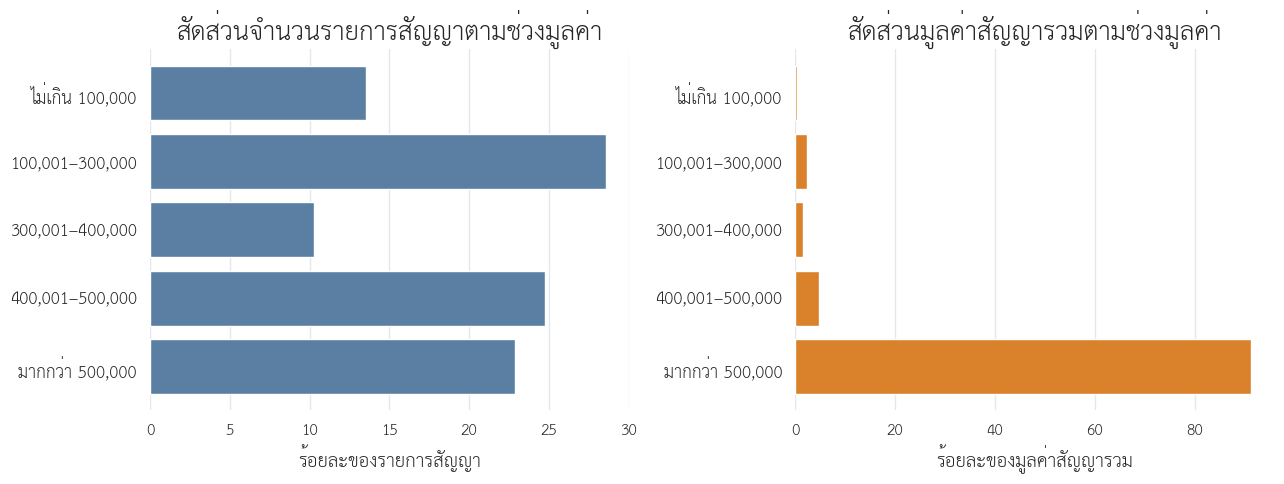

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(
    value_band_summary['ช่วงมูลค่าสัญญา'],
    value_band_summary['สัดส่วนจำนวน (%)'],
    color=BLUE
)
axes[0].set_title('สัดส่วนจำนวนรายการสัญญาตามช่วงมูลค่า')
axes[0].set_xlabel('ร้อยละของรายการสัญญา')
axes[0].set_ylabel('')

axes[1].barh(
    value_band_summary['ช่วงมูลค่าสัญญา'],
    value_band_summary['สัดส่วนมูลค่า (%)'],
    color=ORANGE
)
axes[1].set_title('สัดส่วนมูลค่าสัญญารวมตามช่วงมูลค่า')
axes[1].set_xlabel('ร้อยละของมูลค่าสัญญารวม')
axes[1].set_ylabel('')

for ax in axes:
    ax.invert_yaxis()
    ax.grid(axis='x', color=GRID)
    ax.grid(axis='y', visible=False)
    sns.despine(ax=ax, left=True, bottom=True)

fig.tight_layout()
plt.show()


In [12]:
png_path = figure_dir / 'fig03_01_contract_records_and_value_by_band.png'
svg_path = figure_dir / 'fig03_01_contract_records_and_value_by_band.svg'

fig.savefig(png_path, dpi=180, bbox_inches='tight', facecolor='white')
fig.savefig(svg_path, bbox_inches='tight', facecolor='white')

print(f'Saved: {png_path}')
print(f'Saved: {svg_path}')


Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_01_contract_records_and_value_by_band.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_01_contract_records_and_value_by_band.svg


ตารางและกราฟแสดงสองมุมของช่วงมูลค่าเดียวกัน ได้แก่ สัดส่วนจำนวนรายการสัญญาและสัดส่วนวงเงินรวม เพื่อไม่ให้ช่วงที่มีรายการมากถูกตีความว่าใช้งบประมาณรวมสูงที่สุดโดยอัตโนมัติ


## 3. รายการสัญญารอบ 500,000 บาท


In [13]:
threshold_data = contract_supplier_data.loc[
    contract_supplier_data[contract_value_column].between(400000, 550000)
].copy()

threshold_data['ช่วงละ 10,000 บาท'] = pd.cut(
    threshold_data[contract_value_column],
    bins=range(400000, 550001, 10000),
    right=True,
    include_lowest=True
)

threshold_summary = (
    threshold_data['ช่วงละ 10,000 บาท']
    .value_counts(sort=False)
    .rename_axis('ช่วงมูลค่าสัญญา')
    .reset_index(name='จำนวนรายการสัญญา')
)

display(threshold_summary)


,ช่วงมูลค่าสัญญา,จำนวนรายการสัญญา
0,"(399999.999, 410000.0]",2382
1,"(410000.0, 420000.0]",1751
2,"(420000.0, 430000.0]",1858
3,"(430000.0, 440000.0]",1848
4,"(440000.0, 450000.0]",2521
5,"(450000.0, 460000.0]",2297
6,"(460000.0, 470000.0]",2686
7,"(470000.0, 480000.0]",3853
8,"(480000.0, 490000.0]",7047
9,"(490000.0, 500000.0]",18940


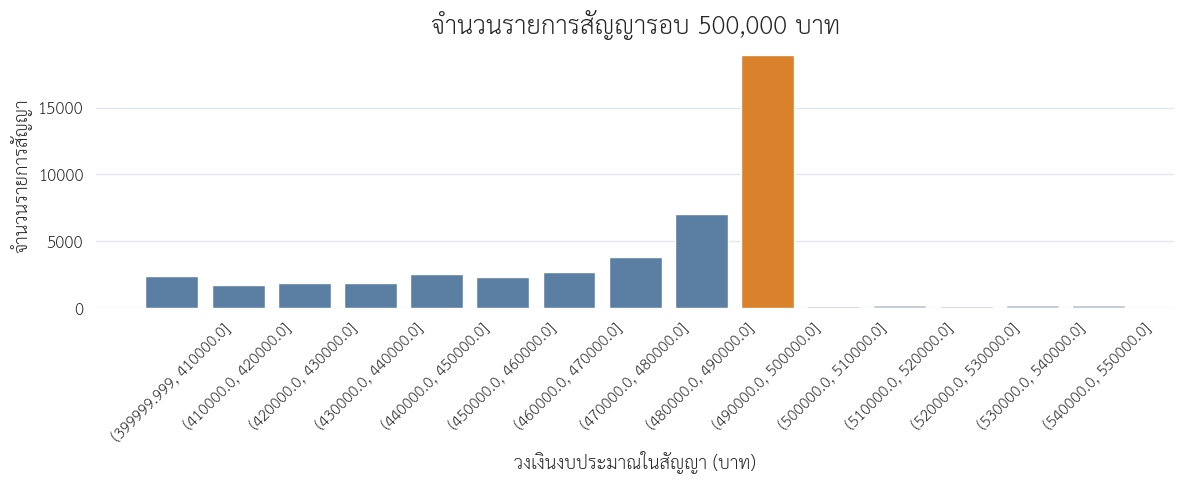

In [14]:
colors = [
    ORANGE if interval.left >= 490000 and interval.right <= 500000
    else GRAY if interval.left >= 500000
    else BLUE
    for interval in threshold_summary['ช่วงมูลค่าสัญญา']
]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(
    threshold_summary['ช่วงมูลค่าสัญญา'].astype(str),
    threshold_summary['จำนวนรายการสัญญา'],
    color=colors
)
ax.set_title('จำนวนรายการสัญญารอบ 500,000 บาท')
ax.set_xlabel('วงเงินงบประมาณในสัญญา (บาท)')
ax.set_ylabel('จำนวนรายการสัญญา')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', color=GRID)
ax.grid(axis='x', visible=False)
sns.despine(ax=ax, left=True, bottom=True)
fig.tight_layout()
plt.show()


In [15]:
png_path = figure_dir / 'fig03_02_contract_value_around_500k.png'
svg_path = figure_dir / 'fig03_02_contract_value_around_500k.svg'

fig.savefig(png_path, dpi=180, bbox_inches='tight', facecolor='white')
fig.savefig(svg_path, bbox_inches='tight', facecolor='white')

print(f'Saved: {png_path}')
print(f'Saved: {svg_path}')


Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_02_contract_value_around_500k.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_02_contract_value_around_500k.svg


สีส้มแสดงช่วง 490,000–500,000 บาท และสีเทาแสดงช่วงที่สูงกว่า 500,000 บาท จึงเห็นการเปลี่ยนแปลงของจำนวนรายการก่อนและหลังเกณฑ์ได้ในภาพเดียว


## 4. วิธีจัดซื้อของรายการสัญญาใกล้ 500,000 บาท


In [17]:
near_ceiling_data = contract_supplier_data.loc[
    contract_supplier_data[contract_value_column].between(
        490000,
        500000
    )
].copy()

method_summary = (
    near_ceiling_data
    .groupby(
        method_column,
        dropna=False
    )
    .agg({
        contract_column: 'size',
        contract_value_column: 'sum'
    })
    .reset_index()
    .rename(columns={
        contract_column: 'จำนวนรายการสัญญา',
        contract_value_column: 'มูลค่าสัญญารวม'
    })
    .sort_values(
        'จำนวนรายการสัญญา',
        ascending=False
    )
    .reset_index(drop=True)
)

method_summary['สัดส่วนจำนวน (%)'] = (
    method_summary['จำนวนรายการสัญญา']
    / method_summary['จำนวนรายการสัญญา'].sum()
    * 100
)

display(method_summary)

,ชื่อวิธีการจัดซื้อจัดจ้าง,จำนวนรายการสัญญา,มูลค่าสัญญารวม,สัดส่วนจำนวน (%)
0,เฉพาะเจาะจง,20200,"10,022,647,412.82",98.78
1,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),238,"118,098,288.61",1.16
2,คัดเลือก,12,"5,977,010.00",0.06


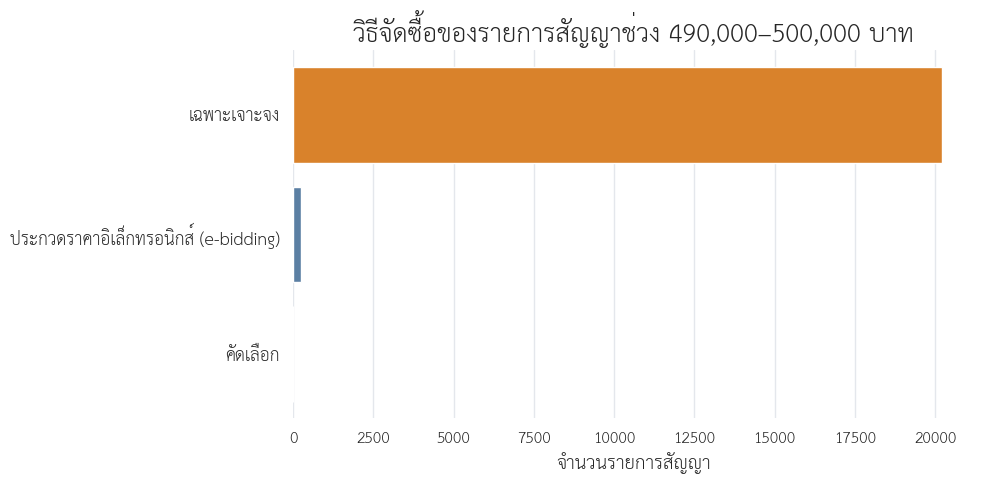

In [18]:
method_chart = method_summary.head(8).sort_values('จำนวนรายการสัญญา')
colors = [ORANGE if method == 'เฉพาะเจาะจง' else BLUE for method in method_chart[method_column]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(method_chart[method_column], method_chart['จำนวนรายการสัญญา'], color=colors)
ax.set_title('วิธีจัดซื้อของรายการสัญญาช่วง 490,000–500,000 บาท')
ax.set_xlabel('จำนวนรายการสัญญา')
ax.set_ylabel('')
ax.grid(axis='x', color=GRID)
ax.grid(axis='y', visible=False)
sns.despine(ax=ax, left=True, bottom=True)
fig.tight_layout()
plt.show()


In [19]:
png_path = figure_dir / 'fig03_03_procurement_method_near_500k.png'
svg_path = figure_dir / 'fig03_03_procurement_method_near_500k.svg'

fig.savefig(png_path, dpi=180, bbox_inches='tight', facecolor='white')
fig.savefig(svg_path, bbox_inches='tight', facecolor='white')

print(f'Saved: {png_path}')
print(f'Saved: {svg_path}')


Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_03_procurement_method_near_500k.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig03_03_procurement_method_near_500k.svg


ตารางแสดงทั้งจำนวนรายการ สัดส่วนจำนวน และมูลค่ารวม ส่วนกราฟใช้เปรียบเทียบจำนวนรายการระหว่างวิธีจัดซื้อในช่วงใกล้เพดาน


## 5. ข้อกำหนดเกี่ยวกับวงเงิน 500,000 บาท

- พระราชบัญญัติการจัดซื้อจัดจ้างฯ พ.ศ. 2560 มาตรา 55 กำหนดวิธีจัดซื้อจัดจ้างพัสดุ 3 วิธี ได้แก่ วิธีประกาศเชิญชวนทั่วไป วิธีคัดเลือก และวิธีเฉพาะเจาะจง
- มาตรา 56 วรรคหนึ่ง (2)(ข) อนุญาตให้ใช้วิธีเฉพาะเจาะจงเมื่อวงเงินต่อครั้งไม่เกินวงเงินที่กำหนดในกฎกระทรวง
- กฎกระทรวงกำหนดวงเงินดังกล่าวไว้ไม่เกิน 500,000 บาท

แหล่งอ้างอิง: [พระราชบัญญัติการจัดซื้อจัดจ้างฯ ในราชกิจจานุเบกษา](https://www.ratchakitcha.soc.go.th/) และ [กฎหมาย/ระเบียบด้านการจัดซื้อจัดจ้างของกรมบัญชีกลาง](https://www.cgd.go.th/)

ข้อกำหนดนี้ช่วยอธิบายว่าทำไมจึงต้องแยกรายการวิธีเฉพาะเจาะจงที่มีวงเงินไม่เกิน 500,000 บาทไปตรวจรูปแบบการกระจุกตัวต่อ


## 6. ขอบเขตสำหรับตรวจรูปแบบต่อ


In [20]:
under_500k_mask = contract_supplier_data[contract_value_column].le(500000)
specific_method_mask = contract_supplier_data[method_column].eq('เฉพาะเจาะจง')
study_scope_mask = under_500k_mask & specific_method_mask

contract_supplier_data['อยู่ในขอบเขตตรวจรูปแบบ'] = study_scope_mask
study_scope_data = contract_supplier_data.loc[study_scope_mask].copy()

scope_summary = pd.DataFrame({
    'ขั้นตอน': [
        'รายการสัญญาจ้างก่อสร้างทั้งหมด',
        'วงเงินไม่เกิน 500,000 บาท',
        'วิธีเฉพาะเจาะจงและวงเงินไม่เกิน 500,000 บาท'
    ],
    'จำนวนรายการสัญญา': [
        len(contract_supplier_data),
        int(under_500k_mask.sum()),
        len(study_scope_data)
    ]
})
scope_summary['สัดส่วนจากทั้งหมด (%)'] = (
    scope_summary['จำนวนรายการสัญญา'] / len(contract_supplier_data) * 100
)

display(scope_summary)


,ขั้นตอน,จำนวนรายการสัญญา,สัดส่วนจากทั้งหมด (%)
0,รายการสัญญาจ้างก่อสร้างทั้งหมด,179716,100.00
1,"วงเงินไม่เกิน 500,000 บาท",138512,77.07
2,"วิธีเฉพาะเจาะจงและวงเงินไม่เกิน 500,000 บาท",136122,75.74


ทุกขั้นตอนนับด้วยหน่วยเดียวกันคือหนึ่งชุดรหัสโครงการ–ผู้รับจ้าง–เลขที่สัญญา แถวสุดท้ายคือขอบเขตข้อมูลที่จะนำไปตรวจ Pattern 1–4 ต่อ


In [21]:
contract_supplier_data.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f'Saved: {output_path}')
print(f'Rows in study scope: {len(study_scope_data):,}')


Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_contract_supplier_study_scope_2569.csv
Rows in study scope: 136,122


## 7. ไฟล์สำหรับวิเคราะห์ต่อ

`construction_contract_supplier_study_scope_2569.csv`

ไฟล์เก็บรายการสัญญาจ้างก่อสร้างทั้งหมด พร้อมคอลัมน์ `อยู่ในขอบเขตตรวจรูปแบบ` สำหรับเลือกข้อมูลใน Notebook 04
